Linhas: 6497
Colunas: 13
<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  style                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


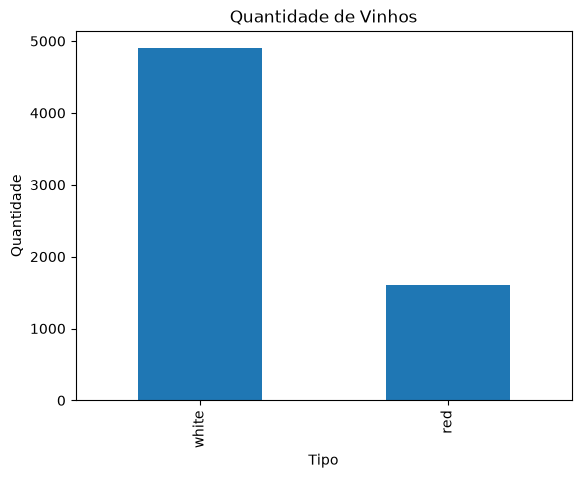

[0 1]
int64
Acurácia: 99.49%
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       462
           1       1.00      1.00      1.00      1488

    accuracy                           0.99      1950
   macro avg       0.99      0.99      0.99      1950
weighted avg       0.99      0.99      0.99      1950



,Acidez_fixa,Acidez_volatil,Acido_citrico,Açucar_residual,cloretos,SO2_livre,total_de_SO2,Densidade,pH,Sulfatos,alcool,qualidade
3772,7.6,0.32,0.58,16.75,0.050,43.0,163.0,0.99990,3.15,0.54,9.200000,5
6009,5.7,0.24,0.47,6.30,0.069,35.0,182.0,0.99391,3.11,0.46,9.733333,5
3464,7.6,0.36,0.44,8.30,0.255,28.0,142.0,0.99580,3.12,0.43,10.200000,6
1518,7.4,0.47,0.46,2.20,0.114,7.0,20.0,0.99647,3.32,0.63,10.500000,5
3761,9.9,0.49,0.23,2.40,0.087,19.0,115.0,0.99480,2.77,0.44,9.400000,6


Vinho 1: Branco
Vinho 2: Branco
Vinho 3: Branco
Vinho 4: Tinto
Vinho 5: Branco


total_de_SO2       0.254851
Acidez_volatil     0.157328
cloretos           0.113077
Densidade          0.105836
Açucar_residual    0.075974
Acidez_fixa        0.073544
Sulfatos           0.063676
pH                 0.048663
SO2_livre          0.048594
Acido_citrico      0.030397
alcool             0.017142
qualidade          0.010918
dtype: float64

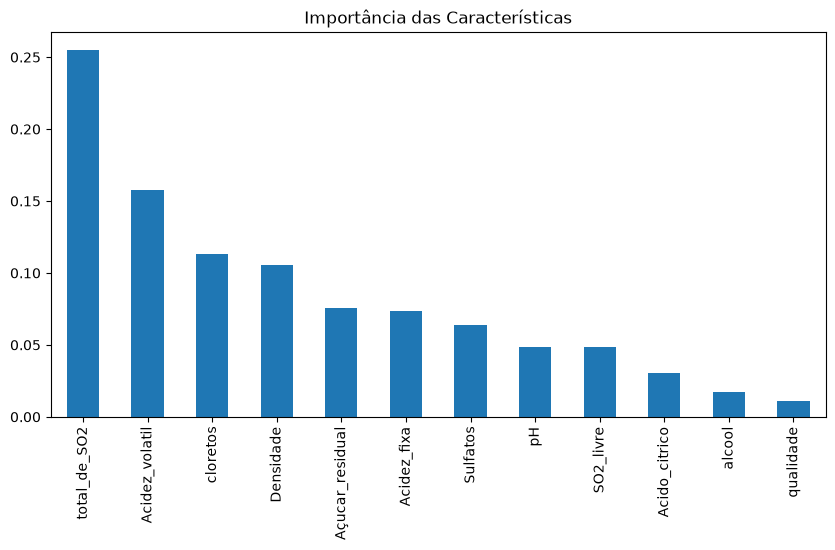

In [6]:
# =============================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =============================================
# CARREGANDO O DATASET
# =============================================

df = pd.read_csv("../data/wine_dataset.csv")

df.head()

# =============================================
# INFORMAÇÕES DO DATASET
# =============================================

print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

df.info()

# =============================================
# ESTATÍSTICAS
# =============================================

df.describe()


# =============================================
# VALORES NULOS
# =============================================

df.isnull().sum()


# =============================================
# QUANTIDADE DE VINHOS
# =============================================

df["style"].value_counts()

# =============================================
# GRÁFICO
# =============================================

df["style"].value_counts().plot(kind="bar")

plt.title("Quantidade de Vinhos")
plt.xlabel("Tipo")
plt.ylabel("Quantidade")
plt.show()


# =============================================
# RENOMEANDO COLUNAS
# =============================================

df.rename(columns={
    'style':'tipo',
    'fixed_acidity':'Acidez_fixa',
    'volatile_acidity':'Acidez_volatil',
    'citric_acid':'Acido_citrico',
    'residual_sugar':'Açucar_residual',
    'chlorides':'cloretos',
    'free_sulfur_dioxide':'SO2_livre',
    'total_sulfur_dioxide':'total_de_SO2',
    'density':'Densidade',
    'sulphates':'Sulfatos',
    'alcohol':'alcool',
    'quality':'qualidade'
}, inplace=True)

df["tipo"] = df["tipo"].map({
    "red": 0,
    "white": 1
}).astype(int)

print(df["tipo"].unique())
print(df["tipo"].dtype)
# =============================================
# SEPARANDO X E Y
# =============================================

X = df.drop("tipo", axis=1)
y = df["tipo"]

# =============================================
# DIVISÃO TREINO/TESTE
# =============================================

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=1
)


# =============================================
# TREINAMENTO
# =============================================

modelo = ExtraTreesClassifier(random_state=1)

modelo.fit(X_treino, y_treino)

# =============================================
# ACURÁCIA
# =============================================

previsoes = modelo.predict(X_teste)

acuracia = accuracy_score(y_teste, previsoes)

print(f"Acurácia: {acuracia:.2%}")

# =============================================
# MATRIZ DE CONFUSÃO
# =============================================

confusion_matrix(y_teste, previsoes)

# =============================================
# RELATÓRIO DE CLASSIFICAÇÃO
# =============================================

print(classification_report(y_teste, previsoes))

# =============================================
# EXEMPLO DE PREDIÇÃO
# =============================================

amostra = X_teste.iloc[0:5]

display(amostra)

resultado = modelo.predict(amostra)

for i, r in enumerate(resultado):

    if r == 0:
        print(f"Vinho {i+1}: Tinto")
    else:
        print(f"Vinho {i+1}: Branco")


# =============================================
# IMPORTÂNCIA DAS CARACTERÍSTICAS
# =============================================

importancias = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

display(importancias)

importancias.plot(kind="bar", figsize=(10,5))

plt.title("Importância das Características")

plt.show()

